In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.special import jv
from scipy.integrate import quad

In [3]:
import sys
sys.path.append('../src/')

In [4]:
from polybessel import PolyBessel

/Users/alexlague/Documents/act/sfb/repo/polybessel/notebooks/../src/interpolation.py:265: SyntaxWarning: invalid escape sequence '\i'
  '''


In [5]:
a = 100.0
b = 400.0
f = lambda x: np.exp(-x/100) * (4*x**2-2)/(37+x)

In [22]:
nu1 = 39
omega1 = 0.01
nu2 = 87
omega2 = 2.1

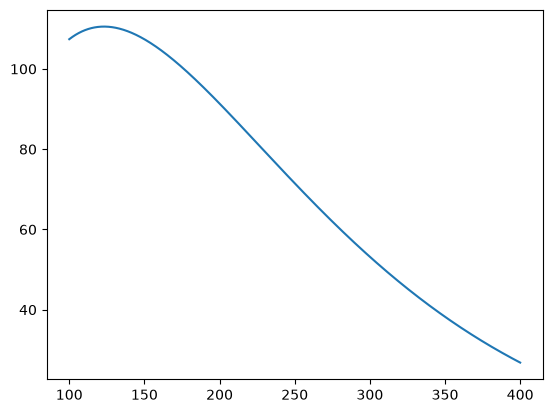

In [12]:
xs = np.linspace(a, b, 1000)
plt.plot(xs, f(xs))

In [8]:
PB = PolyBessel()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [23]:
PB.compute_indiviual_integral_double_bessel(f, nu1, omega1, nu2, omega2, a, b)

0.0

In [24]:
quad(lambda x: f(x) * jv(nu1, omega1*x) * jv(nu2, omega2*x), a, b, epsabs=1e-12, epsrel=1e-6, limit=100000)

(4.849144876696579e-35, 1.5791855075600132e-34)

In [25]:
%timeit PB.compute_indiviual_integral_double_bessel(f, nu1, omega1, nu2, omega2, a, b)

18.5 μs ± 289 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [10]:
'''
from integration import weights_clenshaw_curtis, nodes_clenshaw_curtis #clenshaw_curtis_any_interval #filon_sin_quad, filon_cos_quad
from interpolation import Cheb_coeffs_dct
#from single_bessel_recurrence import precompute_dI_eq33, hankel_transform_multi_l_eq33
from main_integration import main_integration_Bessel_product # move to integration?

c = Cheb_coeffs_dct(f(nodes_clenshaw_curtis(8, a, b)))
u = nodes_clenshaw_curtis(PB.n_cheb_max, -1, 1)
        
main_integration_Bessel_product(c, u, np.ones((8, 2049)), nu1, omega1, nu2, omega2, a, b, ncheb=2048)

PB.w_levels, PB.n_cheb_max
'''

'\nfrom integration import weights_clenshaw_curtis, nodes_clenshaw_curtis #clenshaw_curtis_any_interval #filon_sin_quad, filon_cos_quad\nfrom interpolation import Cheb_coeffs_dct\n#from single_bessel_recurrence import precompute_dI_eq33, hankel_transform_multi_l_eq33\nfrom main_integration import main_integration_Bessel_product # move to integration?\n\nc = Cheb_coeffs_dct(f(nodes_clenshaw_curtis(8, a, b)))\nu = nodes_clenshaw_curtis(PB.n_cheb_max, -1, 1)\n\nmain_integration_Bessel_product(c, u, np.ones((8, 2049)), nu1, omega1, nu2, omega2, a, b, ncheb=2048)\n\nPB.w_levels, PB.n_cheb_max\n'